# 🌳 Decision Tree Classifier

## 📌 Objective
Build a Decision Tree classifier using the Titanic dataset and understand how pruning helps improve model performance.

## 📊 Dataset
Titanic dataset (from seaborn)

## ⚙️ Workflow
1. Load Data  
2. Understand Data  
3. Preprocess Data  
4. Train Model  
5. Apply Pruning  
6. Evaluate Performance  

In [8]:
# Core libraries for data handling
import numpy as np
import pandas as pd

# Visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

# Evaluation metrics
from sklearn.metrics import accuracy_score

In [9]:
# Load Titanic dataset from seaborn
df = sns.load_dataset("titanic")

# Display first 5 rows
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 📊 Data Understanding

- Dataset contains passenger details from Titanic  
- Goal: Predict survival (0 = No, 1 = Yes)  

We will check:
- data types  
- missing values  
- basic statistics  

In [10]:
# Check structure of dataset
df.info()

# Summary statistics
df.describe()

# Check missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

## 🎯 Feature Selection

We select important features for prediction:

- pclass → Passenger class  
- sex → Gender  
- fare → Ticket fare  
- embarked → Port of embarkation  
- age → Age of passenger  

Target variable:
- survived (0 = No, 1 = Yes)

In [11]:
# Selecting relevant features and target

features = ["pclass", "sex", "fare", "embarked", "age"]
target = "survived"

X = df[features]
y = df[target]

X.head()

,pclass,sex,fare,embarked,age
0,3,male,7.2500,S,22.0
1,1,female,71.2833,C,38.0
2,3,female,7.9250,S,26.0
3,1,female,53.1000,S,35.0
4,3,male,8.0500,S,35.0


## ⚠️ Handling Missing Values

Some columns contain missing values:

- age → will be filled using median  
- embarked → will be filled using most frequent value  

Why median?
- Less affected by outliers

In [15]:
# Handle missing values

# For numerical column (age)
num_imputer = SimpleImputer(strategy="median")
X["age"] = num_imputer.fit_transform(X[["age"]])

# For categorical column (embarked)
cat_imputer = SimpleImputer(strategy="most_frequent")
X["embarked"] = cat_imputer.fit_transform(X[["embarked"]]).ravel()

## 🔄 Encoding Categorical Variables

Machine Learning models cannot understand text data.

We convert:
- sex → numerical  
- embarked → numerical  

Using Label Encoding

In [16]:
# Encode categorical features

le = LabelEncoder()

X["sex"] = le.fit_transform(X["sex"])
X["embarked"] = le.fit_transform(X["embarked"])

## ✂️ Train-Test Split

We split data into:

- Training data → used to train model  
- Testing data → used to evaluate performance  

Split ratio:
- 70% training  
- 30% testing  

In [17]:
# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 623
Testing samples: 268


## 🌳 Decision Tree Model (Without Pruning)

First, we train a basic Decision Tree model without any restrictions.

👉 This helps us understand how the model behaves by default.

⚠️ Note:
- Decision Trees can grow very deep
- This often leads to overfitting

In [18]:
# Train decision tree without any constraints

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate performance
print("Accuracy (No Pruning):", accuracy_score(y_test, y_pred))

Accuracy (No Pruning): 0.7798507462686567


## 🌲 Tree Visualization

Visualizing the tree helps understand:
- how decisions are made  
- which features are important  
- how deep the tree has grown  

⚠️ Deep trees usually indicate overfitting

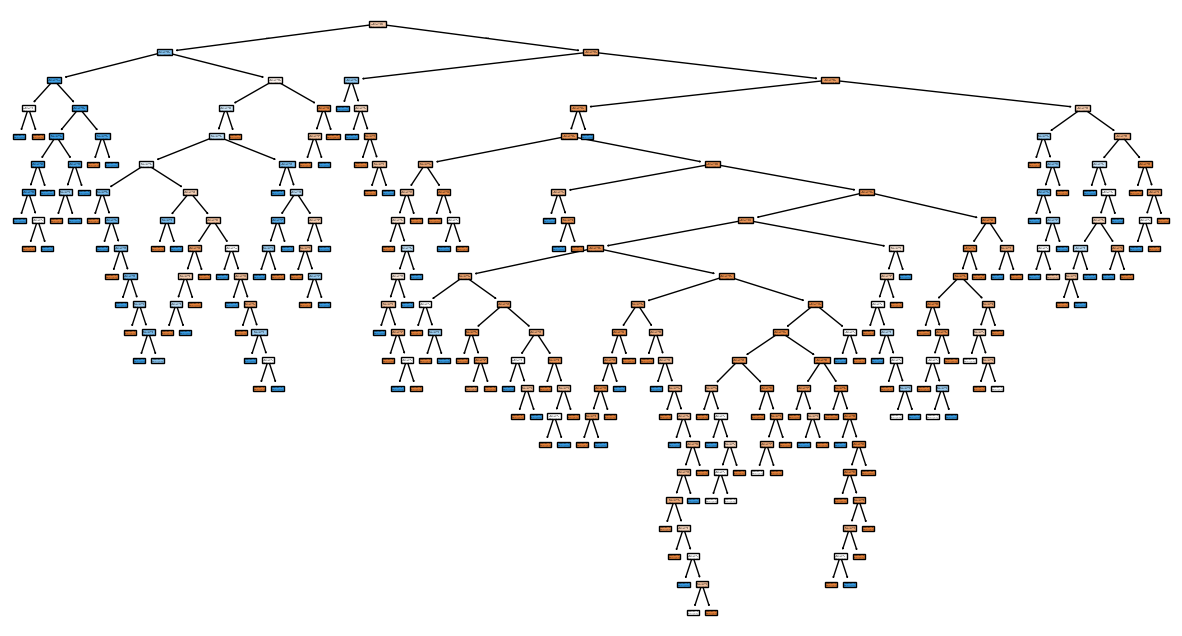

In [19]:
# Visualize decision tree

plt.figure(figsize=(15, 8))
plot_tree(model, feature_names=X.columns, filled=True)
plt.show()

## ✂️ Pre-Pruning (Early Stopping)

Pre-pruning controls tree growth by setting constraints.

Common parameters:
- max_depth → limits tree depth  
- min_samples_split → minimum samples required to split  
- min_samples_leaf → minimum samples in leaf  

👉 Helps reduce overfitting

In [20]:
# Train model with pre-pruning

model_pre = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

model_pre.fit(X_train, y_train)

# Predictions
y_pred_pre = model_pre.predict(X_test)

# Evaluation
print("Accuracy (Pre-Pruning):", accuracy_score(y_test, y_pred_pre))

Accuracy (Pre-Pruning): 0.7835820895522388


## 📊 Comparison

- Without pruning → deeper tree, higher chance of overfitting  
- With pre-pruning → controlled complexity, better generalization  

👉 Pre-pruning helps reduce overfitting but may sometimes underfit

## ✂️ Post-Pruning (Cost Complexity Pruning)

Instead of stopping early, we:

1. Grow a full tree  
2. Remove unnecessary branches  

👉 Controlled using `ccp_alpha`

---

### 🧠 What is ccp_alpha?

- Controls complexity of tree  
- Higher alpha → simpler tree  
- Lower alpha → complex tree  

👉 Goal: find best alpha for best performance

In [21]:
# Get cost complexity pruning path

path = model.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

print("Number of alphas:", len(ccp_alphas))

Number of alphas: 63


## 🔍 Training Models for Different Alpha Values

We train multiple trees using different alpha values  
and compare their performance.

👉 This helps find the optimal pruning level

In [22]:
# Train models for different alpha values

models = []

for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    clf.fit(X_train, y_train)
    models.append((clf, alpha))

## 🎯 Selecting Best Alpha

We evaluate each model on test data  
and select the one with highest accuracy

In [23]:
best_acc = 0
best_alpha = 0

for clf, alpha in models:
    acc = clf.score(X_test, y_test)
    
    if acc > best_acc:
        best_acc = acc
        best_alpha = alpha

print("Best Alpha:", best_alpha)
print("Best Accuracy:", best_acc)

Best Alpha: 0.0017121455323702516
Best Accuracy: 0.8208955223880597


## 🚀 Final Model with Optimal Alpha

We train the final model using best alpha  
to get the best balance between bias and variance

In [24]:
# Train final model

best_model = DecisionTreeClassifier(
    ccp_alpha=best_alpha,
    random_state=42
)

best_model.fit(X_train, y_train)

print("Final Accuracy:", best_model.score(X_test, y_test))

Final Accuracy: 0.8208955223880597


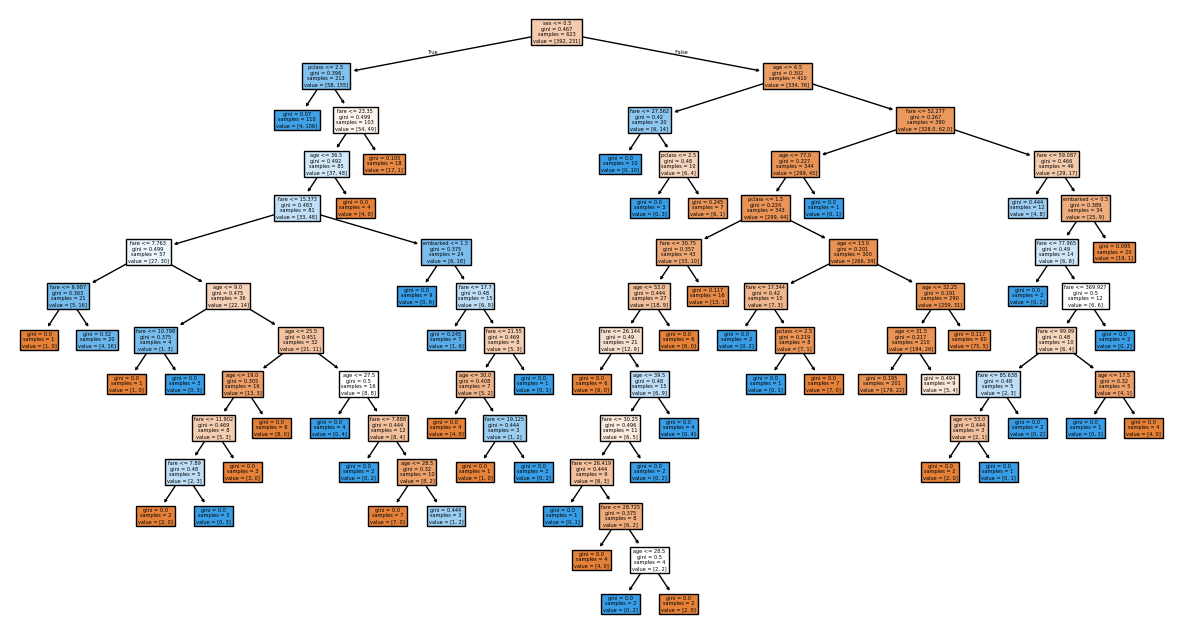

In [25]:
# Visualize final pruned tree

plt.figure(figsize=(15, 8))
plot_tree(best_model, feature_names=X.columns, filled=True)
plt.show()

## 📊 Observations

- Decision Trees without pruning tend to overfit  
- Deep trees memorize training data but perform poorly on unseen data  

---

### 🔍 Pre-Pruning

- Controls tree growth early  
- Reduces overfitting  
- May lead to underfitting if too restrictive  

---

### 🔍 Post-Pruning

- Removes unnecessary branches after full training  
- Provides better control over model complexity  
- Helps find optimal balance between bias and variance  

---

### 📈 Overall Insight

- Model performance depends heavily on tree depth and pruning  
- Proper tuning improves generalization significantly  

## ✅ Conclusion

- Decision Trees are simple and interpretable models  
- They can easily overfit if not controlled  

---

### ✔ Key Takeaways

- Entropy/Gini help in selecting best splits  
- Information Gain determines feature selection  
- Pruning is essential for controlling model complexity  

---

### 🚀 Final Understanding

- Pre-pruning → limits growth early  
- Post-pruning → optimizes tree after training  

👉 A well-pruned tree gives better real-world performance

## 🧠 One-Line Summary

> Decision Trees split data based on impurity reduction, and pruning helps control overfitting to improve generalization.